In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style set karo
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

print("Libraries imported ")

Libraries imported 


In [4]:

df = pd.read_csv("../data/diabetes_prediction_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.head()

Shape: (100000, 9)

Columns:
 ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data Types:
 gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing Values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicates: 3854


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:

print("Numerical Summary:")
df.describe()

Numerical Summary:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Diabetes Distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


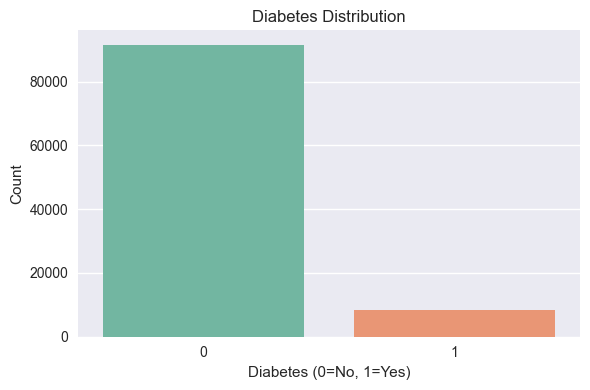

In [6]:

print("Diabetes Distribution:")
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(
    x=df['diabetes'],
    hue=df['diabetes'],
    palette='Set2',
    legend=False
)
plt.title('Diabetes Distribution')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
print(df[df['age'] < 1]['age'].value_counts())
print("Count:", len(df[df['age'] < 1]))


age
0.72    104
0.80    102
0.64     99
0.56     96
0.88     90
0.32     89
0.24     87
0.48     83
0.40     66
0.16     59
0.08     36
Name: count, dtype: int64
Count: 911


In [8]:
print(df[df['bmi'] > 60]['bmi'].describe())
print("Count:", len(df[df['bmi'] > 60]))

count    115.000000
mean      66.680696
std        7.712817
min       60.030000
25%       61.820000
50%       64.310000
75%       67.960000
max       95.690000
Name: bmi, dtype: float64
Count: 115


In [9]:

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


Duplicate rows: 3854
After removing duplicates: (96146, 9)


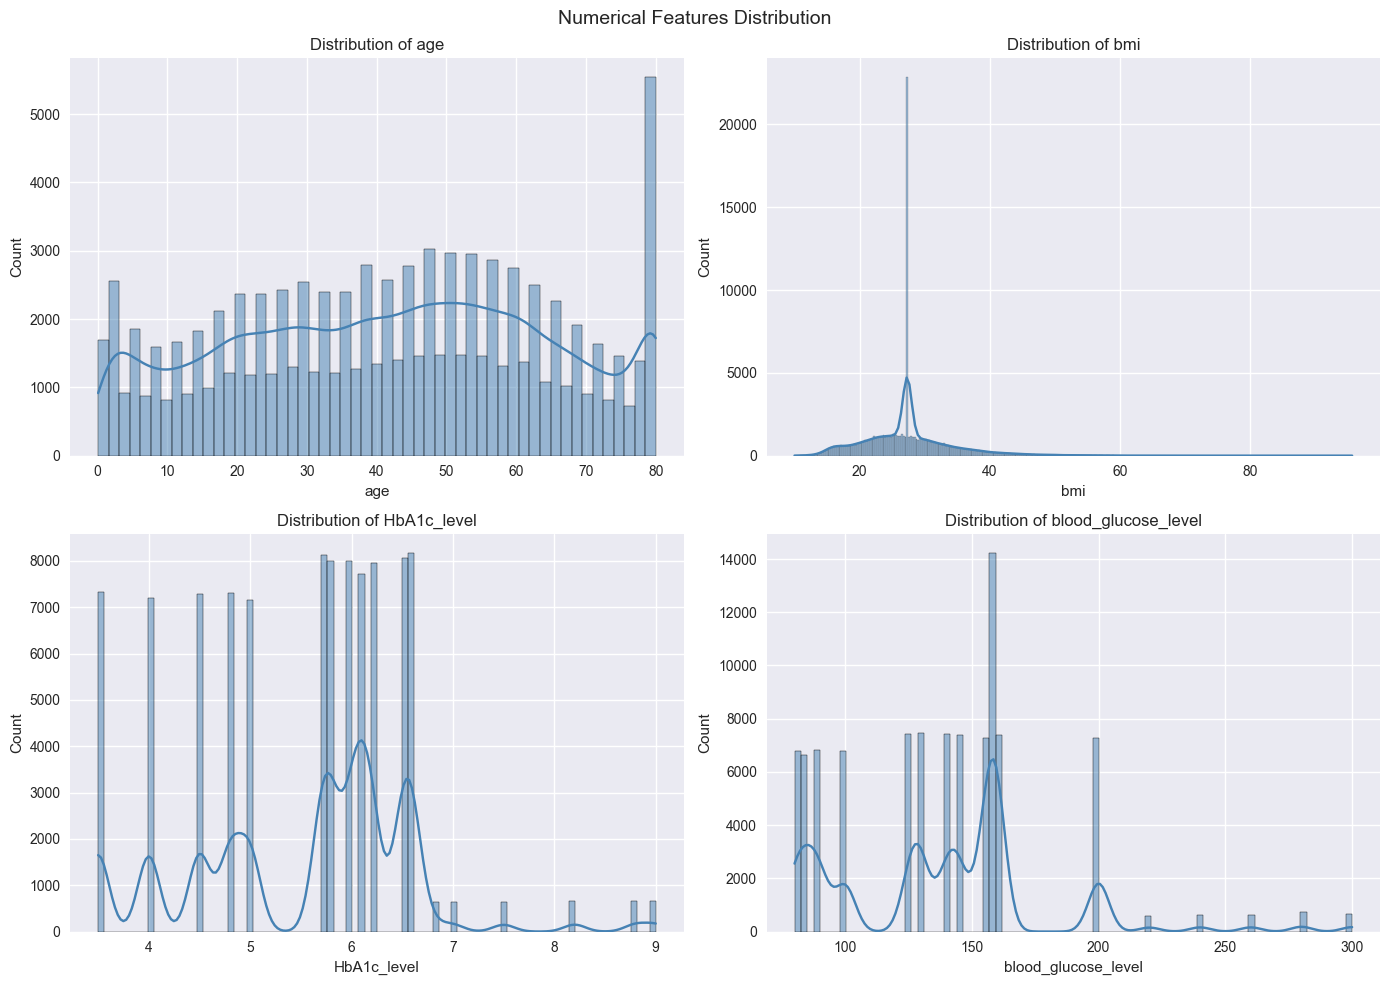

In [11]:
# UNIVARIATE — NUMERICAL

numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(14, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.suptitle('Numerical Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

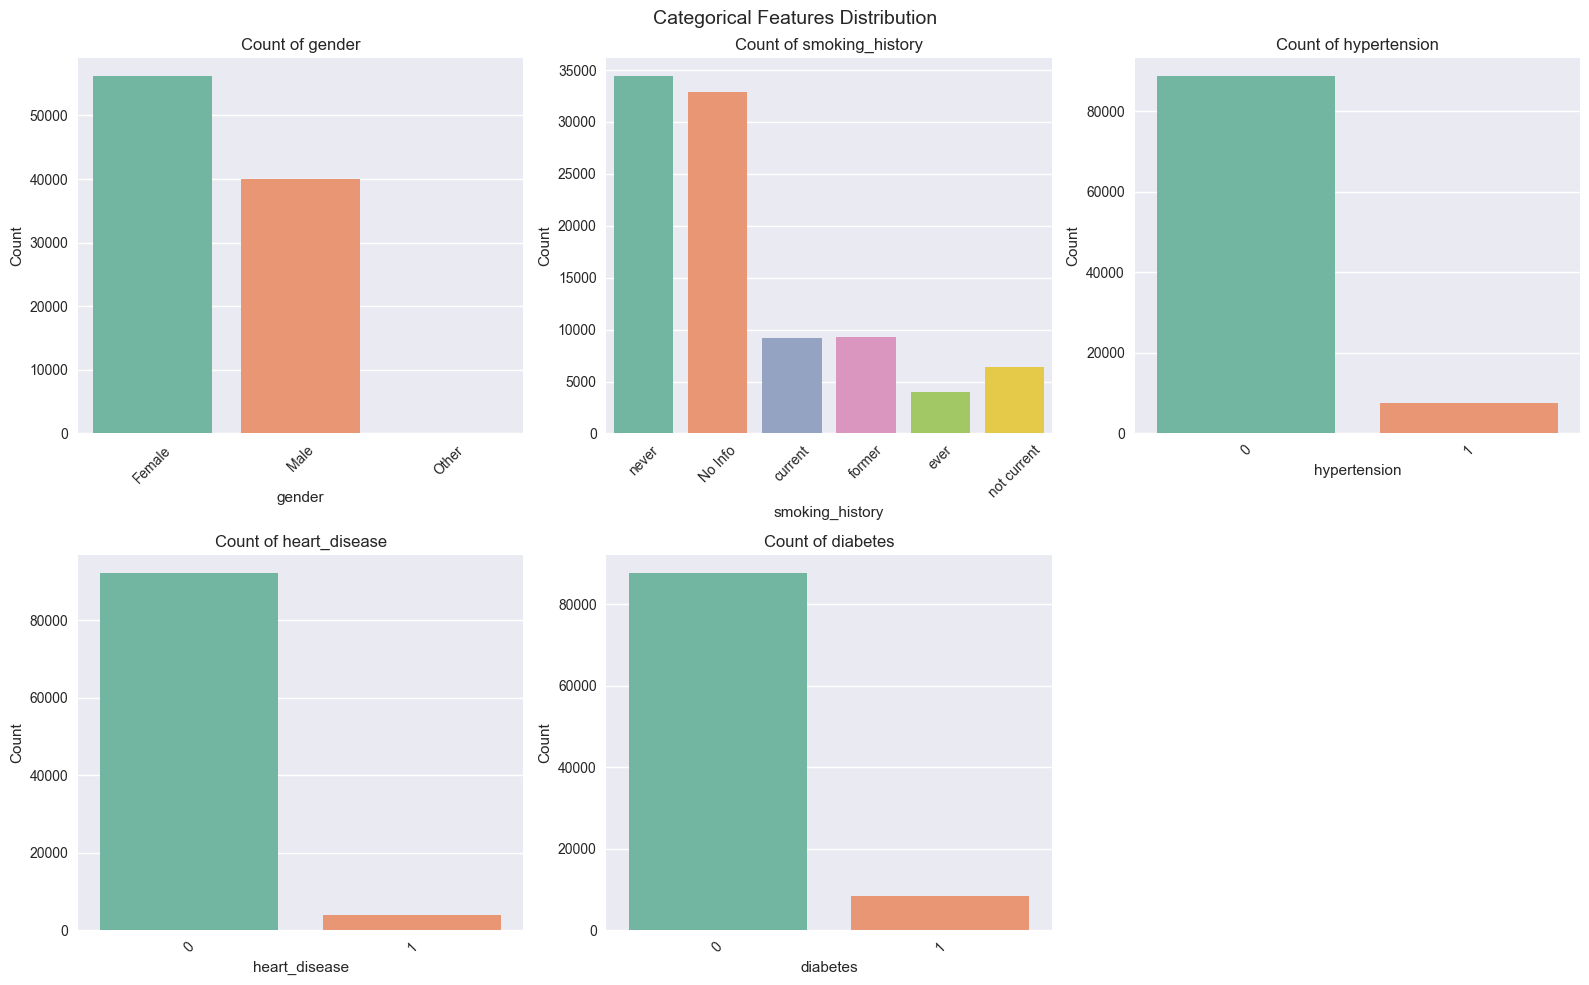

In [ ]:
#  UNIVARIATE — CATEGORICAL

categorical_cols = ['gender', 'smoking_history',
                    'hypertension', 'heart_disease', 'diabetes']

plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(
        x=df[col],
        hue=df[col],
        palette='Set2',
        legend=False
    )
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
plt.suptitle('Categorical Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

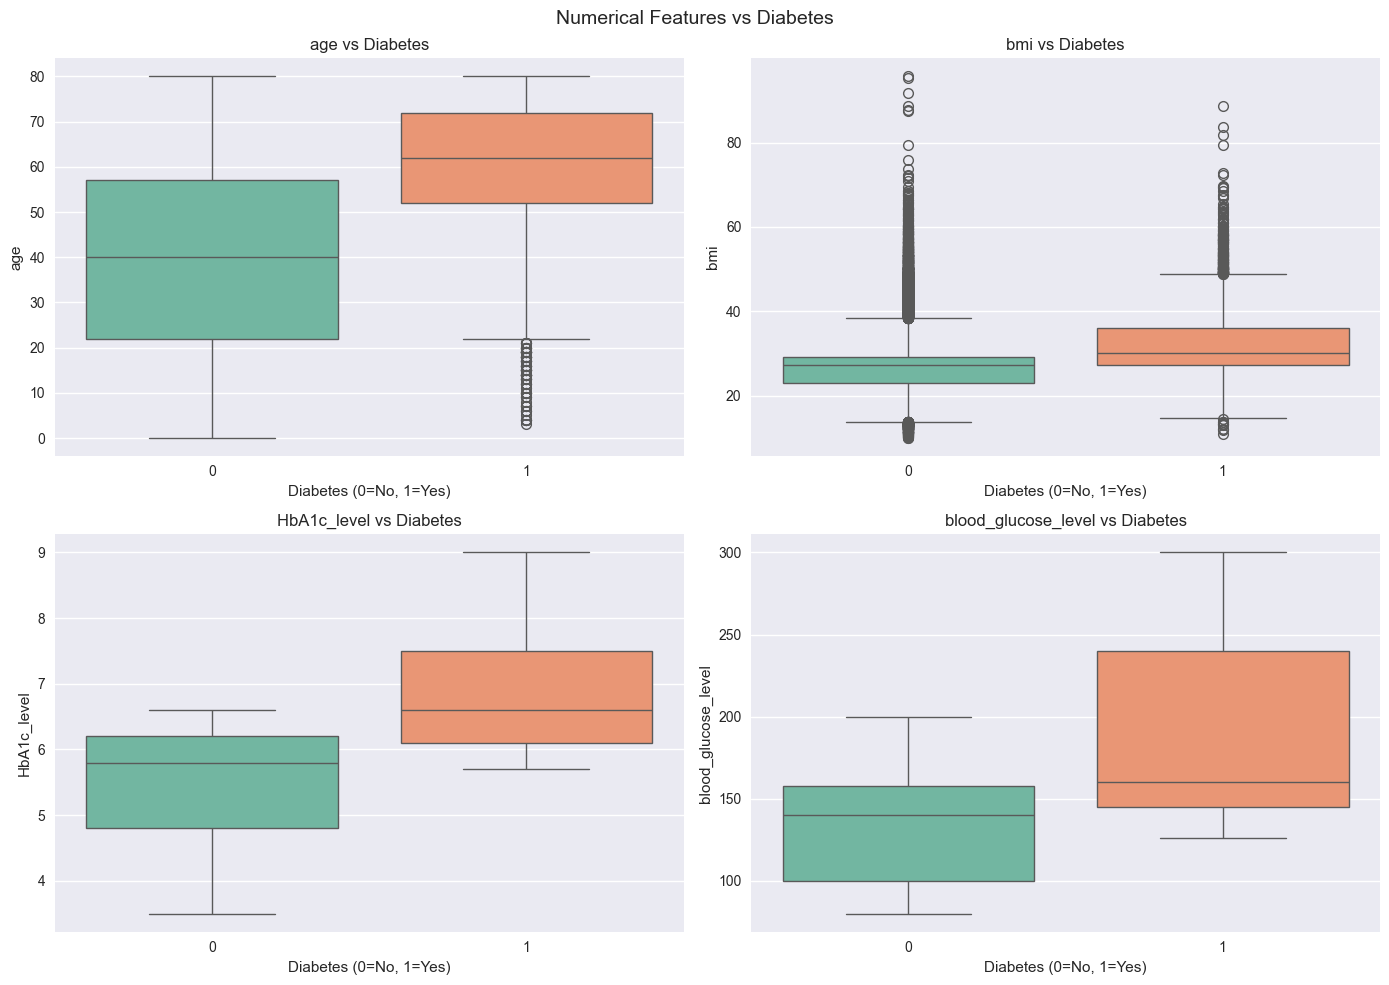

In [13]:
# BIVARIATE — Numerical vs Diabetes
plt.figure(figsize=(14, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        x=df['diabetes'],
        y=df[col],
        hue=df['diabetes'],
        palette='Set2',
        legend=False
    )
    plt.title(f'{col} vs Diabetes')
    plt.xlabel('Diabetes (0=No, 1=Yes)')
    plt.ylabel(col)
plt.suptitle('Numerical Features vs Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

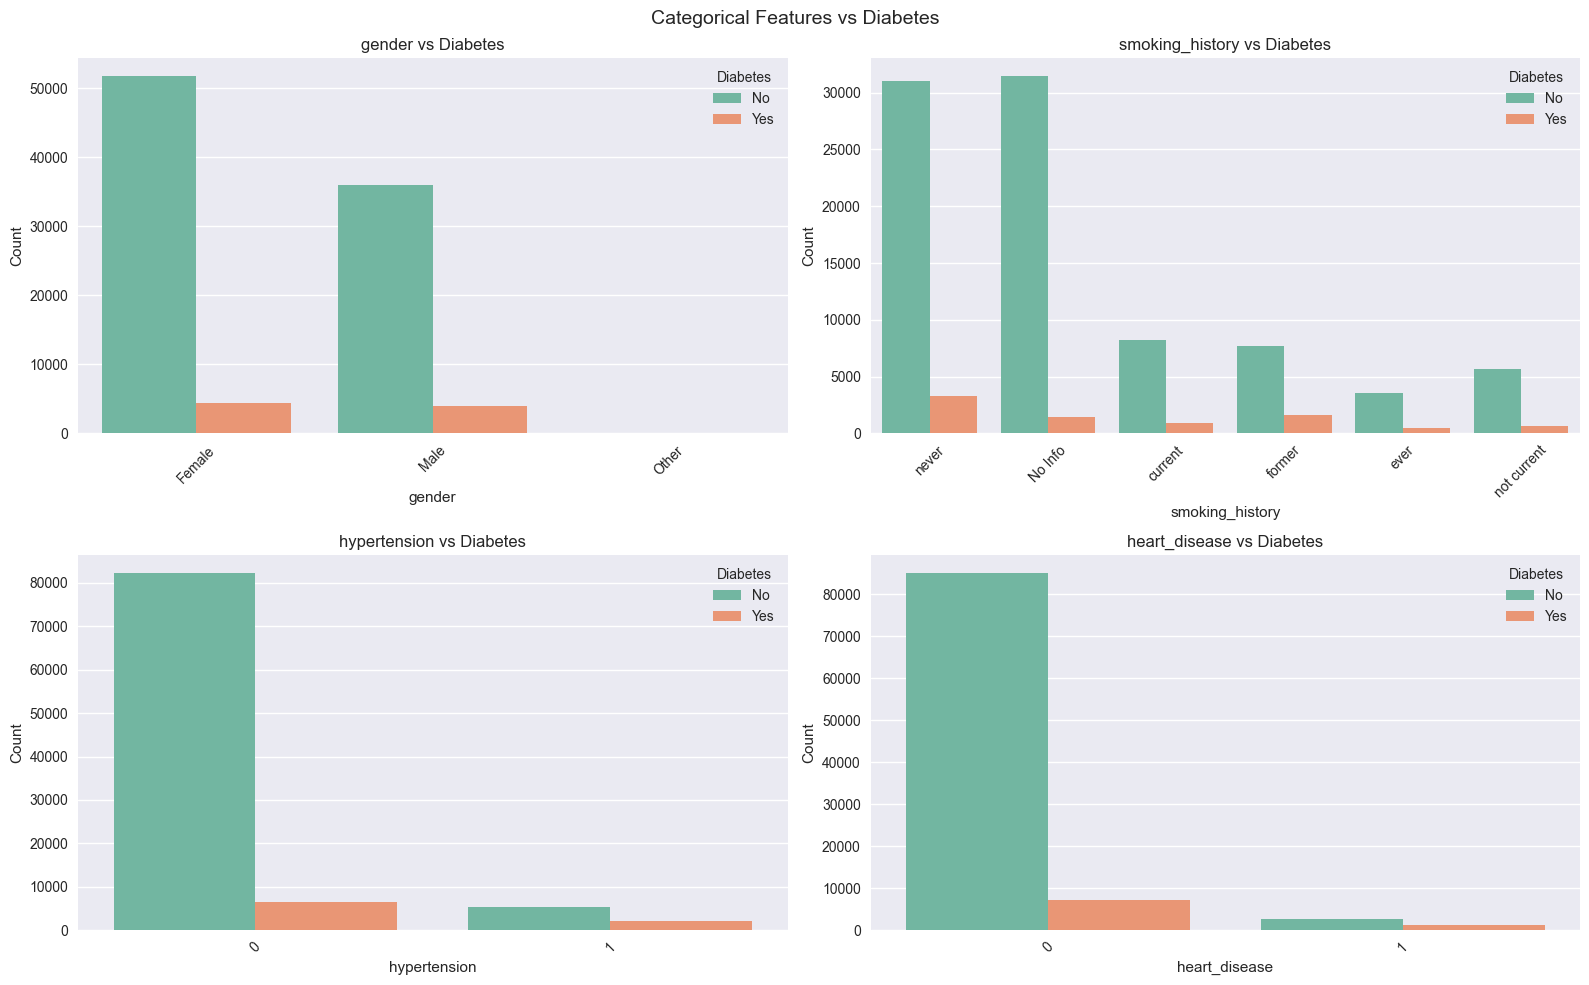

In [14]:
# BIVARIATE — Categorical vs Diabetes
cat_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(
        x=df[col],
        hue=df['diabetes'],
        palette='Set2'
    )
    plt.title(f'{col} vs Diabetes')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.suptitle('Categorical Features vs Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

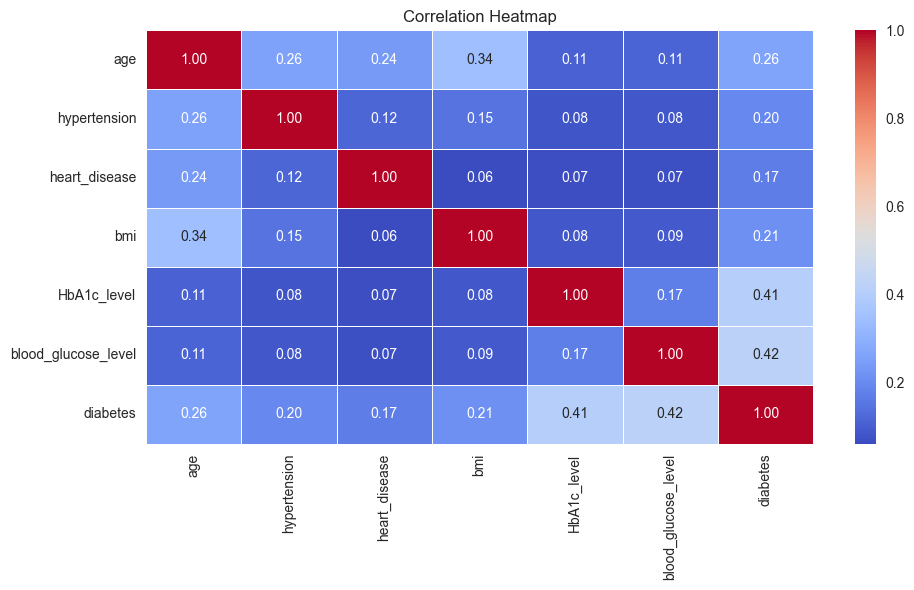

In [15]:
# CORRELATION HEATMAP

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
# Class Imbalance -> SMOTE lagana padega
# HbA1c & Glucose -> Sabse strong predictors
# Age & BMI       -> Moderate predictors
# Gender          -> Weak predictor